<a href="https://colab.research.google.com/github/01PrathamS/Stable_Diffusion_from_scratch/blob/main/notebooks/VAE_implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [ ]:
transform = transforms.ToTensor()
train_loader = DataLoader(datasets.MNIST(root="./data", train=True, transform=transform, download=True), batch_size=64, shuffle=True)



In [9]:
class VAE(nn.Module):
  def __init__(self):
    super(VAE, self).__init__()
    self.encoder = nn.Sequential(
        nn.Linear(28*28, 128),
        nn.ReLU()
    )
    self.fc_mu = nn.Linear(128, 32)
    self.fc_logvar = nn.Linear(128, 32)

    self.decoder = nn.Sequential(
        nn.Linear(32, 128),
        nn.ReLU() ,
        nn.Linear(128, 28*28),
        nn.Sigmoid()
    )

  def reparameterize(self, mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

  def forward(self, x):
    x = self.encoder(x)
    mu = self.fc_mu(x)
    logvar = self.fc_logvar(x)
    z = self.reparameterize(mu, logvar)
    return self.decoder(z), mu, logvar



In [10]:
def loss_function(recon_x, x, mu, logvar):
  recon_loss = nn.functional.mse_loss(recon_x, x, reduction="sum")
  kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
  return recon_loss + kl_loss

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

vae = VAE().to(device)
optimizer = optim.Adam(vae.parameters(), lr=0.001)

for epoch in range(5):
  for images, _ in train_loader:
    images = images.view(-1, 28*28).to(device)
    optimizer.zero_grad()
    recon_images, mu, logvar = vae(images)
    loss = loss_function(recon_images, images, mu, logvar)
    loss.backward()
    optimizer.step()

  print(f"Epoch [{epoch+1}/5], Loss: {loss.item():.4f}")

torch.save(vae.state_dict(), "vae.pth")

Epoch [1/5], Loss: 1271.0931
Epoch [2/5], Loss: 1151.9814
Epoch [3/5], Loss: 1137.3866
Epoch [4/5], Loss: 1146.4232
Epoch [5/5], Loss: 1103.5999


<ipython-input-12-230734efa32d>:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vae.load_state_dict(torch.load("vae.pth"))


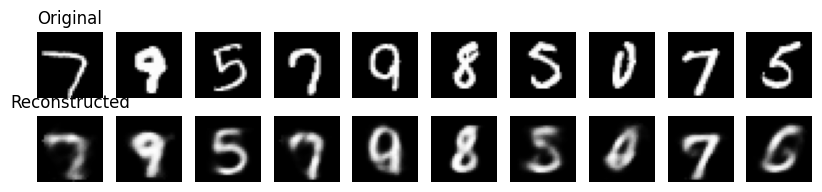

In [12]:
import matplotlib.pyplot as plt
import torch

# Load trained VAE model
vae.load_state_dict(torch.load("vae.pth"))
vae.eval()

# Get a batch of test images
test_images, _ = next(iter(train_loader))
test_images = test_images.view(-1, 28*28).to(device)

# Reconstruct images
with torch.no_grad():
    reconstructed, _, _ = vae(test_images)

# Convert to numpy for visualization
test_images = test_images.cpu().view(-1, 28, 28)
reconstructed = reconstructed.cpu().view(-1, 28, 28)

# Plot original and reconstructed images side by side
fig, axes = plt.subplots(2, 10, figsize=(10, 2))
for i in range(10):
    axes[0, i].imshow(test_images[i], cmap="gray")  # Original
    axes[1, i].imshow(reconstructed[i], cmap="gray")  # Reconstructed
    axes[0, i].axis('off')
    axes[1, i].axis('off')

axes[0, 0].set_title("Original")
axes[1, 0].set_title("Reconstructed")
plt.show()


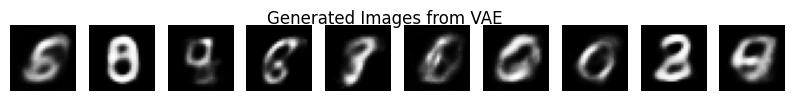

In [13]:
z = torch.randn(10, 32).to(device)  # 10 new samples

# Generate new images
with torch.no_grad():
    new_images = vae.decoder(z)

new_images = new_images.cpu().view(-1, 28, 28)

fig, axes = plt.subplots(1, 10, figsize=(10, 1))
for i in range(10):
    axes[i].imshow(new_images[i], cmap="gray")
    axes[i].axis('off')

plt.suptitle("Generated Images from VAE")
plt.show()
